# AI-Based Crop Yield Prediction — EDA & Results
CNN-LSTM Fusion Architecture | IEEE-Level Academic Project

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_preprocessing import load_data, split_data
from src.feature_engineering import compute_vegetation_indices, extract_temporal_stats
from src.utils import compute_metrics, format_results_table
print('Imports OK')

Imports OK


In [2]:
images, weather, yields, crop_labels = load_data()
crop_names = {0: 'Wheat', 1: 'Rice', 2: 'Maize'}
print(f'Images:  {images.shape}')
print(f'Weather: {weather.shape}')
print(f'Yields:  {yields.shape}')
df = pd.DataFrame({'crop': [crop_names[c] for c in crop_labels], 'yield': yields})
print('\nYield stats per crop:')
print(df.groupby('crop')['yield'].describe().round(3))

Images:  (500, 16, 32, 32, 7)
Weather: (500, 16, 6)
Yields:  (500,)

Yield stats per crop:
       count   mean    std    min    25%    50%    75%    max
crop                                                         
Maize  129.0  2.360  1.111  0.500  1.388  2.201  3.138  5.043
Rice    93.0  2.990  1.214  0.857  2.039  3.097  3.715  5.615
Wheat  278.0  1.508  0.775  0.500  0.926  1.297  1.936  3.945


In [ ]:
ndvi, evi = compute_vegetation_indices(images)
ndvi_spatial = ndvi.mean(axis=(2, 3))  # (N, T)
mean_curve = ndvi_spatial.mean(axis=0)
std_curve  = ndvi_spatial.std(axis=0)
weeks = np.arange(1, len(mean_curve) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(weeks, mean_curve, 'g-', linewidth=2, label='Mean NDVI')
ax.fill_between(weeks, mean_curve - std_curve, mean_curve + std_curve, alpha=0.3, color='green', label='±1 std')
ax.set_xlabel('Week'); ax.set_ylabel('NDVI'); ax.set_title('Seasonal NDVI Trend')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
wx_mean = weather.mean(axis=1)
wx_df = pd.DataFrame(wx_mean, columns=['Rainfall','Temp Max','Temp Min','Humidity','Solar Rad','Soil Moisture'])
wx_df['Yield'] = yields
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(wx_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', ax=ax)
ax.set_title('Weather–Yield Correlation Heatmap')
plt.tight_layout(); plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for ct, name in crop_names.items():
    mask = crop_labels == ct
    ax.violinplot(yields[mask], positions=[ct], showmedians=True)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(list(crop_names.values()))
ax.set_ylabel('Yield (t/ha)'); ax.set_title('Yield Distribution per Crop Type')
plt.tight_layout(); plt.show()

In [ ]:
import tensorflow as tf
from src.cnn_model import build_cnn_encoder
from config import IMAGE_HEIGHT, IMAGE_WIDTH, NUM_BANDS
cnn = build_cnn_encoder((IMAGE_HEIGHT, IMAGE_WIDTH, NUM_BANDS + 2))
print(f'CNN encoder parameters: {cnn.count_params():,}')

In [ ]:
from src.lstm_model import build_lstm_encoder
from config import SEQUENCE_LENGTH, NUM_WEATHER_FEATURES
lstm = build_lstm_encoder((SEQUENCE_LENGTH, NUM_WEATHER_FEATURES))
print(f'LSTM encoder parameters: {lstm.count_params():,}')

In [ ]:
from src.fusion_model import build_fusion_model
fusion = build_fusion_model(
    (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, NUM_BANDS + 2),
    (SEQUENCE_LENGTH, NUM_WEATHER_FEATURES)
)
print(f'Fusion model total parameters: {fusion.count_params():,}')

In [ ]:
# Run full training pipeline
import subprocess
result = subprocess.run(['python', 'src/train.py'], capture_output=True, text=True, cwd=os.path.dirname(os.getcwd()))
print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[-1000:])

In [ ]:
import json
from config import RESULTS_DIR
results_path = os.path.join(RESULTS_DIR, 'all_model_results.csv')
if os.path.exists(results_path):
    df_results = pd.read_csv(results_path, index_col=0)
    print(df_results.round(4))
else:
    print('Run evaluate.py first')

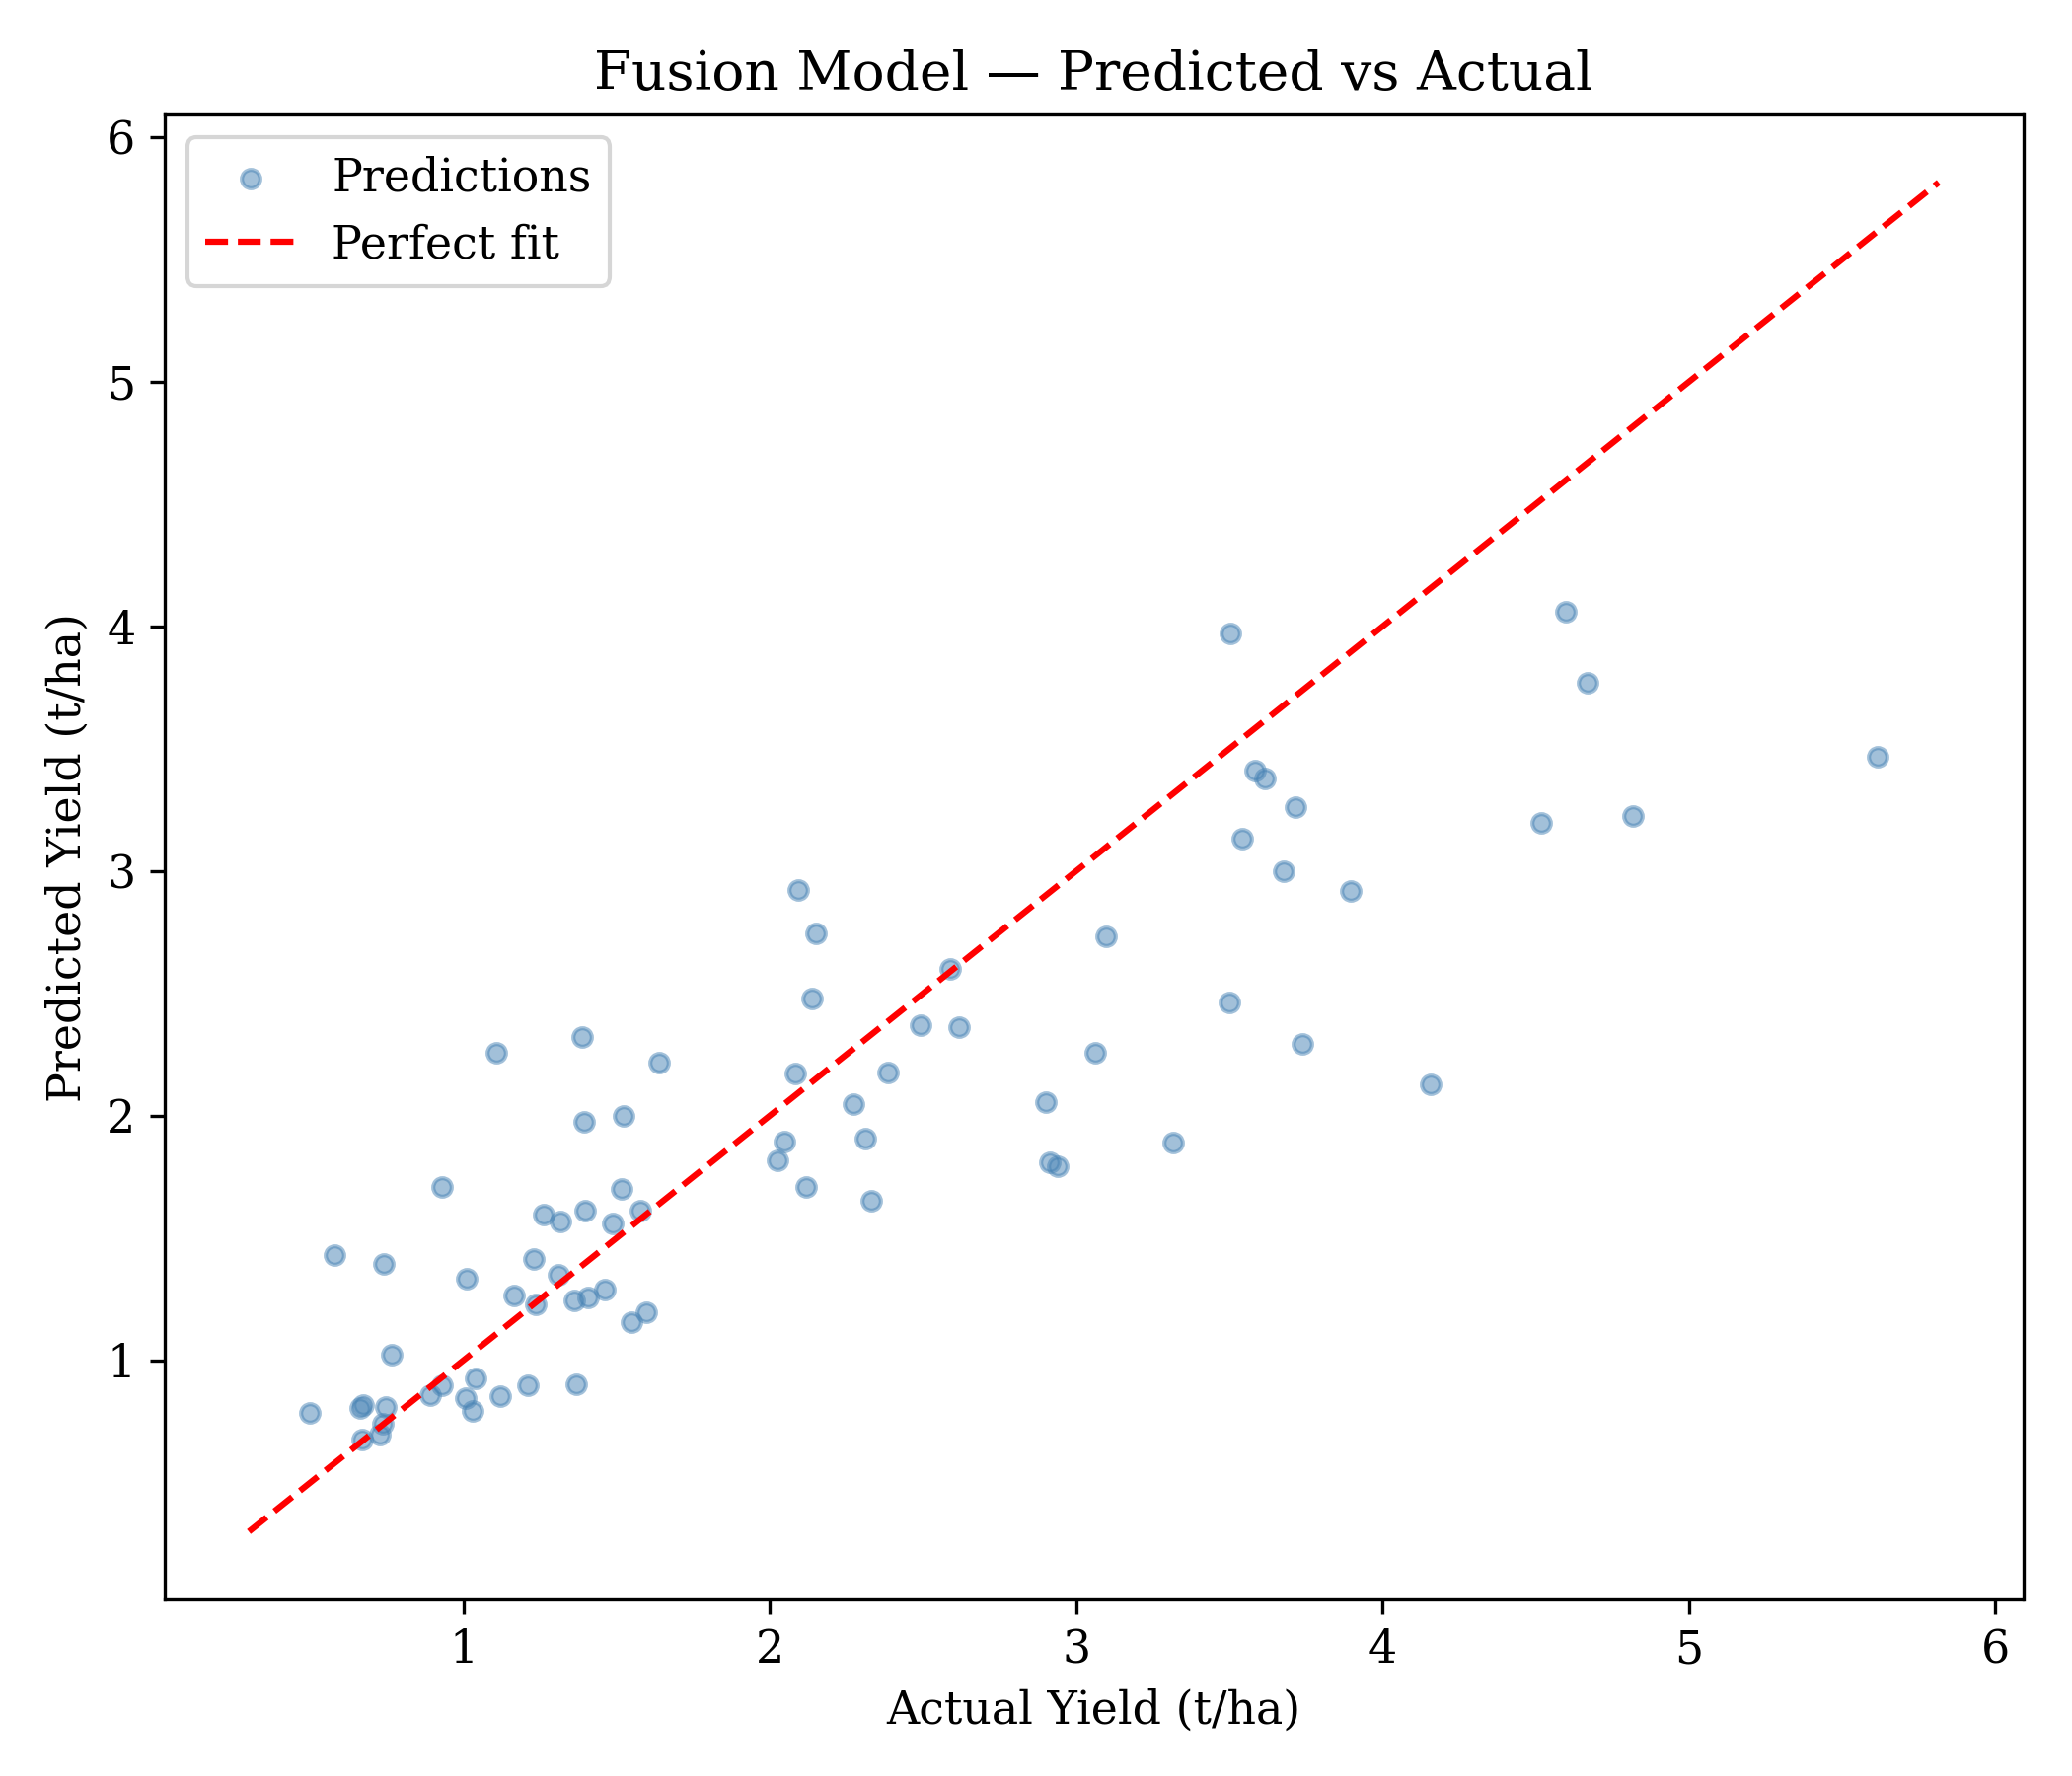

In [3]:
from config import PLOT_DIR
img_path = os.path.join(PLOT_DIR, 'predicted_vs_actual.png')
if os.path.exists(img_path):
    from IPython.display import Image
    display(Image(img_path))
else:
    print('Run evaluate.py to generate plots')

In [4]:
print('=== PROJECT SUMMARY ===')
print(f'Dataset: {len(yields)} fields, {images.shape[1]} timesteps, {images.shape[-1]} channels')
print(f'Yield range: {yields.min():.2f} – {yields.max():.2f} t/ha')
print(f'Fusion model params: {fusion.count_params():,}')
results_path = os.path.join(RESULTS_DIR, 'all_model_results.csv')
if os.path.exists(results_path):
    df_r = pd.read_csv(results_path, index_col=0)
    best = df_r['R2'].idxmax()
    print(f'Best model: {best} (R²={df_r.loc[best, "R2"]:.4f})')

=== PROJECT SUMMARY ===
Dataset: 500 fields, 16 timesteps, 7 channels
Yield range: 0.50 – 5.62 t/ha


NameError: name 'fusion' is not defined